In [ ]:
from iminuit import Minuit
from fitter.src.fitter.analysis.fitter import Fitter
import psutil
import os
import time
import torch
from fitter.src.fitter.config import GlobalConfig as gcfg
import json

# 改成单核
torch.set_num_threads(1)

start_time = time.perf_counter()
process = psutil.Process(os.getpid())
initial_cpu = process.cpu_times()
gseed = 0  # 0 for Asimov >0 for toy
year = 50 / 365.25  # 1年统计量
gcfg.use_poisson = False  # 是否使用泊松分布
gcfg.test_statistic = 0
# gcfg.monitoring = True
junosyst = Fitter(
    year,
    n_E_nu_bins=5600,  # 默认对应0.002 MeV步长 (13.0-1.8)/5600≈0.002
    n_E_dep_bins=5600,  # 默认对应0.002 MeV步长 (12.0-0.8)/5600≈0.002
    n_E_d_bins=560,
    n_E_p_bins=560,
)
junosyst.get_obs_spectrum(gseed)
# junosyst.initial_params_inverted对应逆序拟合，junosyst.initial_params_normal对应正序拟合
m = Minuit(junosyst.chi2, junosyst.NO_params_NO, name=junosyst.names)
m.tol = 0.01
# m.fixed["alpha_rho_ME"] = True
results = m.migrad()
display(results)

# 输出用于生成数据的真值参数（需先调用 get_obs_spectrum）
try:
    junosyst.get_truth_params(as_dict=True, print_out=True)
except Exception as e:
    print("无法输出真值参数:", e)


# 仍然输出带误差与精度的信息
for name in m.parameters:
    print(f"{name}: {m.values[name]} ± {m.errors[name]}")
    print(f"precision: {m.errors[name] / m.values[name]}")

errors_dict = {}
for name in m.parameters:
    errors_dict[name] = round(float(m.errors[name]), 6)

    # errors_dict[name] = float(m.errors[name])
with open("parameter_errors.json", "w") as f:
    json.dump(errors_dict, f, indent=2)

print("参数误差已保存到 parameter_errors.json")
print("可以通过以下方式读取：")
print("with open('parameter_errors.json', 'r') as f:")
print("    data = json.load(f)")
print("    print(data['sinsq13'])  # 获取sinsq13的误差")


/cvmfs/gastpc.ihep.ac.cn/linux-ubuntu2404-x86_64_v3-gcc1330/Release/J24.1.2/external/linux-ubuntu24.04-x86_64_v3/gcc-13.3.0/python-venv-1.0-qspfwwiproypir6felddagikgsmdfood/lib/python3.11/site-packages/torch/utils/_device.py:106: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return func(*args, **kwargs)


Parameters used to generate data:
dmsq31:  0.0025303
dmsq21:  7.53e-05
sinsq12:  0.307
sinsq13:  0.0219


KeyboardInterrupt: 

In [3]:
print(m.values["alpha_reactor1"])

0.0


In [3]:
# 保存 m.values 和 m.errors 到同一个 JSON 文件，供缩放使用
import json

results_dict = {"values": {}, "errors": {}}
for name in m.parameters:
    results_dict["values"][name] = float(m.values[name])
    results_dict["errors"][name] = float(m.errors[name])

with open("parameter_values_and_errors.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("参数拟合值与误差已保存到 parameter_values_and_errors.json")


参数拟合值与误差已保存到 parameter_values_and_errors.json


In [5]:
for i in m.parameters:
    print(m.values[i])

print(m.fval)

0.0025303005485374968
0.30700569999336874
7.530022823663032e-05
0.021900026485492108
9.407861961446714e-06
1.518080861491573e-07
1.5581853736873765e-07
9.585768358751732e-08
9.4299566554018e-08
1.0219345957055286e-07
1.0067185057933295e-07
1.0782329227208683e-07
1.0633258374305539e-07
6.958193110213004e-07
9.407861961446714e-06
-6.660757813838315e-08
-0.00016520077060559605
0.00012559907852320053
-1.4847696759020385e-05
-0.00011851294964333292
3.093240949800166e-07
-7.613648202393211e-05
-1.6223108681793722e-05
2.2335828169677878e-05
8.531539967565545e-05
-5.450298211382366e-05
-9.113045228185441e-09
-1.0585093576127652e-08
-4.915835839223811e-09
1.1462030426418612e-06
-1.99473922323926e-05
-3.640901518051984e-05
1.081519589359582e-06


In [4]:
print(m.fval)
# 将拟合值保存到一个list里面
fit_para_values = [m.values[name] for name in m.parameters]
print("chi", junosyst.chi2(fit_para_values))
params_init = junosyst.get_truth_params(as_dict=False, print_out=True)
# pass the Python list/tuple directly (do not wrap in torch.tensor)
chi2_init = junosyst.chi2(params_init)
print(f"initial chi2: {chi2_init:.8e}")

1.081519589359582e-06
chi tensor(1.0815e-06)


TypeError: unsupported operand type(s) for -: 'str' and 'float'

In [6]:
import numpy as np

params_SGD = np.loadtxt("fitted_params_approximate.txt")


chi2_fit_SGD = junosyst.chi2(params_SGD)
print(f"SGD fit chi2: {chi2_fit_SGD:.16e}")

params_minuit = [m.values[name] for name in m.parameters]
chi2_fit_minuit = junosyst.chi2(params_minuit)
print(f"Minuit fit chi2: {chi2_fit_minuit:.16e}")


FileNotFoundError: fitted_params_approximate.txt not found.

In [4]:
# 计算第0次迭代的梯度，并输出初值、两种梯度、以及一步更新后的值
from fitter.src.fitter.analysis.juno_syst import JunoSyst
from fitter.src.fitter.config import GlobalConfig as gcfg
from fitter.src.fitter.fitting_frame.torch_helper import gradient_step0_report

gcfg.monitoring = False
# 构造 Asimov 数据
year = 50 / 365.25
gcfg.use_poisson = False
junosyst = JunoSyst(
    year,
    n_E_nu_bins=5600,
    n_E_dep_bins=5600,
    n_E_d_bins=560,
    n_E_p_bins=560,
)
junosyst.get_obs_spectrum(seed=1)

# 在未使用参数缩放的物理空间上报告梯度（便于和手工差分对比）
report = gradient_step0_report(junosyst, lr=1e-9, use_parameter_scaling=True, eps_rel=1e-6)


/data/juno/xuejq/paper/reactor-neutrino-fitter/fitter/src/fitter/reactor/reactor_expected.py:330: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  flux_per_fission = torch.sum(10**exponents * torch.tensor(rcfg.fission_fractions).view(-1, 1), dim=0)
/data/juno/xuejq/paper/reactor-neutrino-fitter/fitter/src/fitter/reactor/reactor_expected.py:916: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pdfs.append(torch.tensor(bin_values, dtype=torch.float64))
/data/juno/xuejq/paper/reactor-neutrino-fitter/fitter/src/fitter/analysis/juno_syst.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True),

>>>>>>>>>>>>Finish Scaling IBD spectral shape uncertainty
Total number of parameters for JUNO: 32
Total number of parameters for fit: 32
Parameters used to generate data:
dmsq31:  0.0025303
dmsq21:  7.53e-05
sinsq12:  0.307
sinsq13:  0.0219
>>>>>>>>> reactor neutrino number per day: 47.29
>>>>>>>>> background number per day: 3.88
background_spectrum sum:  tensor(193.9946)
day_bkg:  49.99992533134217
Initial parameters (physical), Grad at step 0 (backward & finite-diff), and Updated (physical):
dmsq31: init=2.5303000000e-03, grad_bwd=3.9797564451e+04, grad_fd=3.9782875561e+04, updated=2.5303000000e-03
sinsq12: init=3.0702000000e-01, grad_bwd=-5.9676077125e+02, grad_fd=-5.9676077126e+02, updated=3.0702000003e-01
dmsq21: init=7.5303000000e-05, grad_bwd=1.4564159903e+06, grad_fd=1.4544498233e+06, updated=7.5302999999e-05
sinsq13: init=2.1890000000e-02, grad_bwd=-5.6671262607e+01, grad_fd=-5.6671262541e+01, updated=2.1890000000e-02
alpha_RC: init=0.0000000000e+00, grad_bwd=1.3533065290e+02,

In [2]:
# 计算梯度值
from src.fitter.analysis.juno_syst import JunoSyst
from src.fitter.config import GlobalConfig as gcfg

year = 50 / 365.25
junosyst = JunoSyst(
    year,
    n_E_nu_bins=5600,
    n_E_dep_bins=5600,
    n_E_d_bins=560,
    n_E_p_bins=560,
)

junosyst.get_obs_spectrum(seed=1)
params_true = junosyst.get_truth_params(as_dict=False, print_out=True)
print("params_true", params_true)
params_init = junosyst.fit_para_init
print("params_init", params_init)
params_init_dict = {name: junosyst.fit_para_init[i].item() for i, name in enumerate(junosyst.fit_para_names)}

gradient = 2 * (params_true["sinsq13"] - params_init_dict["sinsq13"]) / (gcfg.sigma_sinsq13) ** 2
print("gradient", gradient)

>>>>>>>>>>>>Finish Scaling IBD spectral shape uncertainty
Total number of parameters for JUNO: 32
Total number of parameters for fit: 32
Parameters used to generate data:
dmsq31:  0.0025303
dmsq21:  7.53e-05
sinsq12:  0.307
sinsq13:  0.0219
>>>>>>>>> reactor neutrino number per day: 47.29
>>>>>>>>> background number per day: 3.88
background_spectrum sum:  tensor(193.9946)
day_bkg:  49.99992533134217
params_true {'dmsq31': 0.0025303, 'sinsq12': 0.307, 'dmsq21': 7.53e-05, 'sinsq13': 0.0219, 'alpha_RC': -0.003495441841103239, 'alpha_RUCs_TS_C1': -0.002339654007720709, 'alpha_RUCs_TS_C2': -0.006255267698854737, 'alpha_RUCs_YJ_C1': -0.0020575379249509656, 'alpha_RUCs_YJ_C2': 6.513744414674806e-05, 'alpha_RUCs_YJ_C3': -0.0022048232423949633, 'alpha_RUCs_YJ_C4': 0.010352510515185659, 'alpha_RUCs_YJ_C5': 0.008053794522446355, 'alpha_RUCs_YJ_C6': -0.021689299831727748, 'alpha_RUCs_DYB_6Cs': -0.03701694866889635, 'alpha_D': -0.004221904115763535, 'alpha_bkg_AccBkgHistogramAD': 0.0002842224131579

In [6]:
from src.fitter.fitting_frame.torch_helper import scan_lr_schedule
from src.fitter.analysis.juno_syst import JunoSyst

year = 50 / 365.25
junosyst = JunoSyst(year, n_E_nu_bins=5600, n_E_dep_bins=5600, n_E_d_bins=560, n_E_p_bins=560)
junosyst.get_obs_spectrum(seed=1)

result = scan_lr_schedule(
    juno_syst=junosyst,
    initial_params=None,  # 或传入物理空间的初值序列
    candidate_lrs=None,
    n_steps=50,
    use_parameter_scaling=True,  # 与你当前的训练设定一致
    plot_dir="lr_scans",
    verbose=True,
)

print("chosen_lrs:", result["chosen_lrs"])
print("loss_changes:", result["loss_changes"])
print("final_loss:", result["loss_history"][-1])

/cvmfs/gastpc.ihep.ac.cn/linux-ubuntu2404-x86_64_v3-gcc1330/Release/J24.1.2/external/linux-ubuntu24.04-x86_64_v3/gcc-13.3.0/python-venv-1.0-qspfwwiproypir6felddagikgsmdfood/lib/python3.11/site-packages/torch/utils/_device.py:106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
2026-02-05 18:00:59.808 | INFO     | src.fitter.fitting_frame.model:_load_parameter_scales:98 - Loaded parameter scaling factors from ./data/Xuejq/scale_factor_juno.json
2026-02-05 18:00:59.810 | INFO     | src.fitter.fitting_frame.model:_load_parameter_scales:99 - Found scaling factors for 32 parameters


>>>>>>>>>>>>Finish Scaling IBD spectral shape uncertainty
Total number of parameters for JUNO: 32
Total number of parameters for fit: 32
Parameters used to generate data:
dmsq31:  0.0025303
dmsq21:  7.53e-05
sinsq12:  0.307
sinsq13:  0.0219
>>>>>>>>> reactor neutrino number per day: 47.29
>>>>>>>>> background number per day: 3.88
background_spectrum sum:  tensor(193.9946)
day_bkg:  49.99992533134217


2026-02-05 18:01:00.731 | INFO     | src.fitter.fitting_frame.torch_helper:scan_lr_schedule:750 - Step 000: loss_before=6.2670252752942952e+02, best_lr=1.438e-01, delta=2.391991e+01, loss_after=6.0278261430232476e+02
2026-02-05 18:01:02.222 | INFO     | src.fitter.fitting_frame.torch_helper:scan_lr_schedule:750 - Step 001: loss_before=6.0278261430232476e+02, best_lr=2.976e-01, delta=1.096369e+00, loss_after=6.0168624501300144e+02
2026-02-05 18:01:03.380 | INFO     | src.fitter.fitting_frame.torch_helper:scan_lr_schedule:750 - Step 002: loss_before=6.0168624501300144e+02, best_lr=2.637e-01, delta=4.435618e-01, loss_after=6.0124268320616045e+02
2026-02-05 18:01:04.304 | INFO     | src.fitter.fitting_frame.torch_helper:scan_lr_schedule:750 - Step 003: loss_before=6.0124268320616045e+02, best_lr=2.336e-01, delta=2.106663e-01, loss_after=6.0103201687190688e+02
2026-02-05 18:01:05.272 | INFO     | src.fitter.fitting_frame.torch_helper:scan_lr_schedule:750 - Step 004: loss_before=6.0103201687

chosen_lrs: [tensor(0.1438), tensor(0.2976), tensor(0.2637), tensor(0.2336), tensor(0.2336), tensor(0.2336), tensor(0.2336), tensor(0.2336), tensor(0.2637), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2976), tensor(0.2069), tensor(0.2637), tensor(0.2336), tensor(0.2637), tensor(0.2336), tensor(0.2336), tensor(0.2336), tensor(0.3793), tensor(0.2069), tensor(0.1624), tensor(0.7848), tensor(0.1438), tensor(0.2637), tensor(0.1833), tensor(0.8859), tensor(0.1438), tensor(0.1129), tensor(0.1274), tensor(0.1624), tensor(0.2976), tensor(0.6952), tensor(0.2976), tensor(0.4281)]
loss_changes: [23.919913227104757, 1.0963692893233201, 0.44356180684098945, 0.21066633425357395, 0.08669746221687546, 0.03344461710253199, 0.012844346562701503, 0.005043619190928439, 0.00

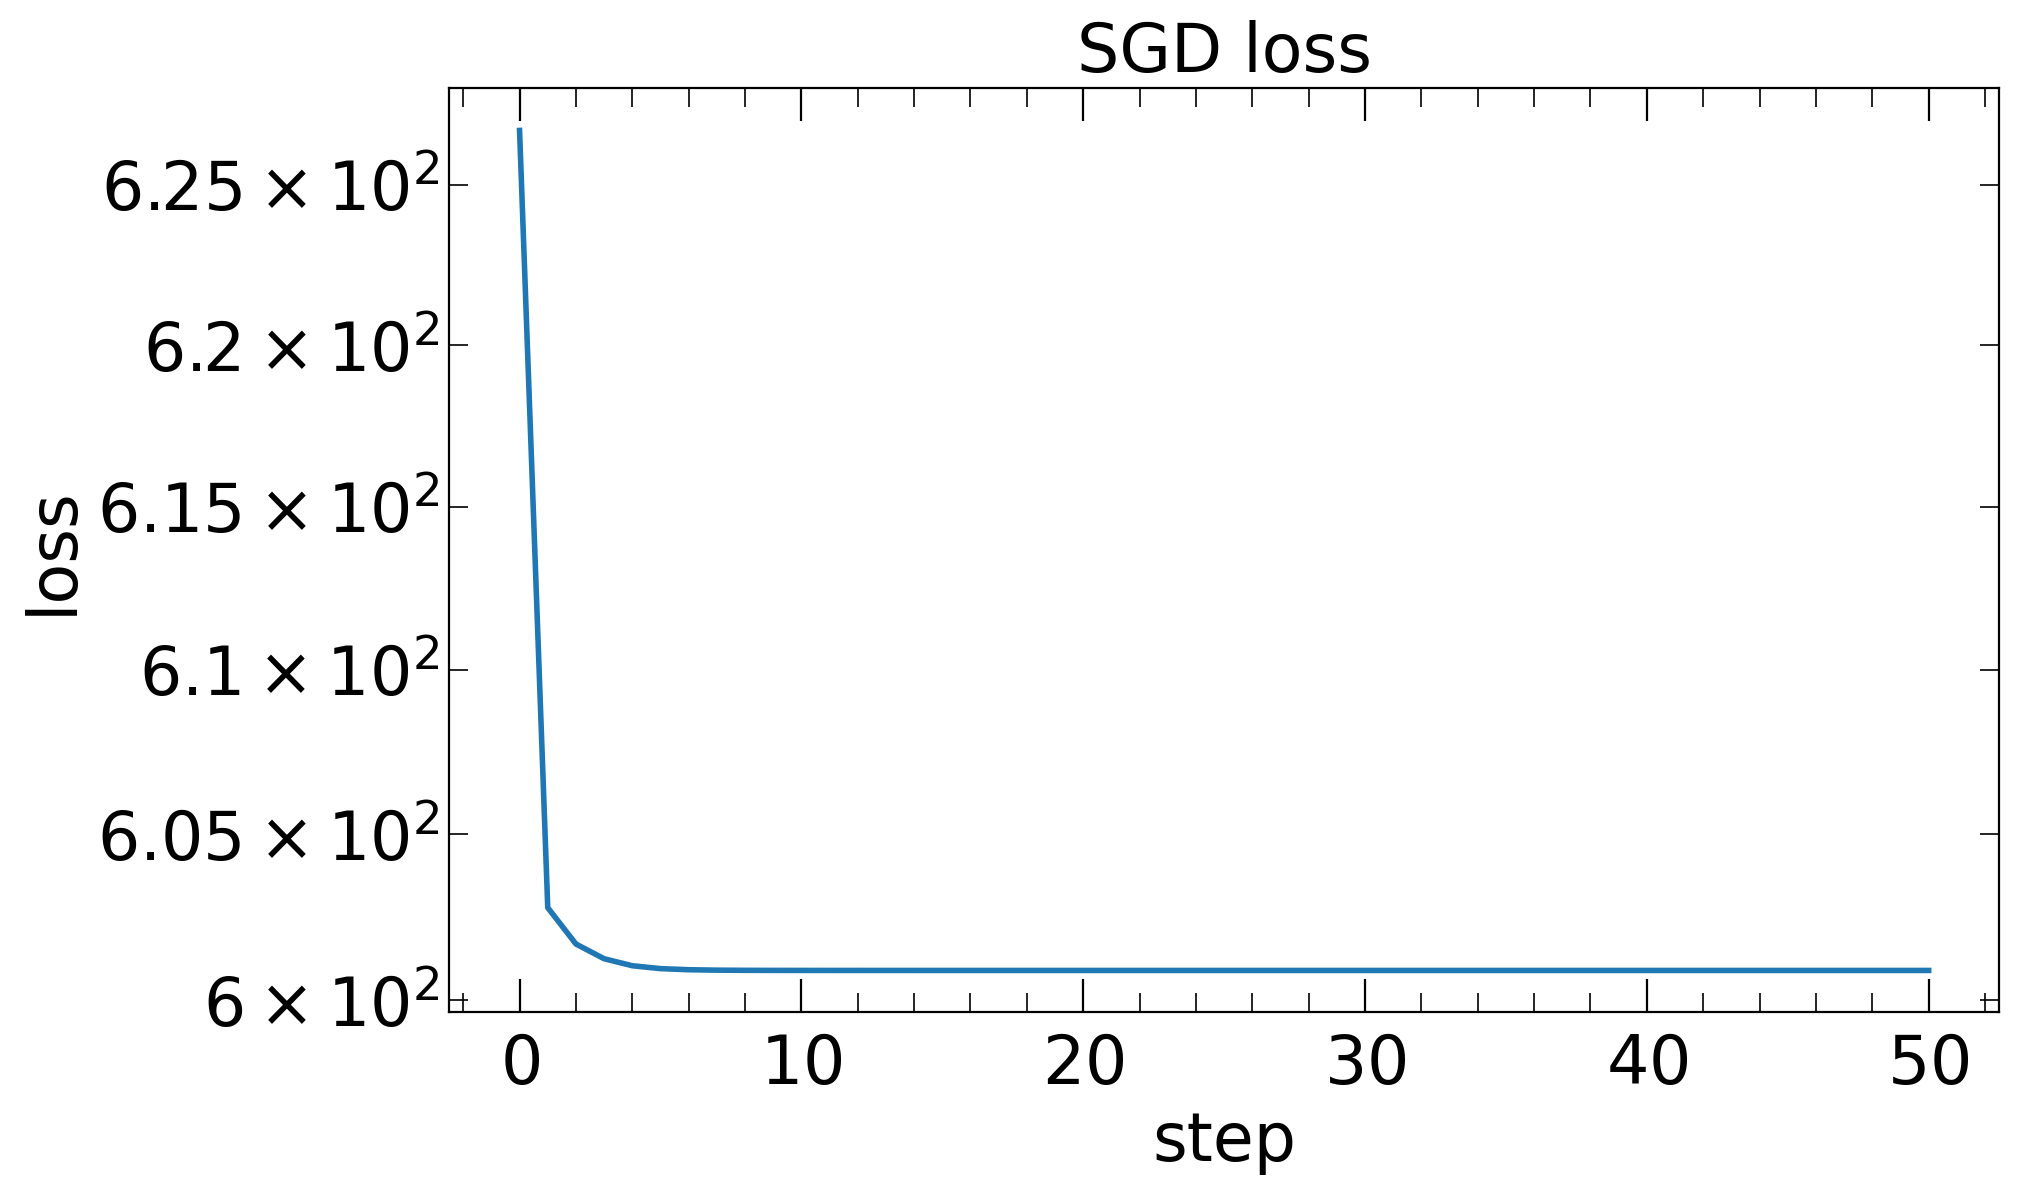

In [7]:
import matplotlib.pyplot as plt

plt.style.use("./lib/Paper.mplstyle")
plt.figure(figsize=(10, 6))
plt.plot(result["loss_history"])
plt.xlabel("step")
plt.ylabel("loss")
plt.yscale("log")
plt.title("SGD loss")
plt.show()


In [9]:
import json
results_dict = {}
for i, lr in enumerate(result["chosen_lrs"]):
    results_dict[i] = float(lr)

with open("learning_rate.json", "w") as f:
    json.dump(results_dict, f, indent=5)

print("参数拟合值与误差已保存到 learning_rate.json")

参数拟合值与误差已保存到 learning_rate.json
